In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch

C:\Users\yjais\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.1)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [2]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")


[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.469200,37.689860,36.593684,36.750281,148158800
2019-01-03,33.737000,34.574552,33.691918,34.161706,365248800
2019-01-04,35.177200,35.246010,34.118992,34.292196,234428400
2019-01-07,35.098904,35.312446,34.617252,35.281600,219111200
2019-01-08,35.768002,36.021879,35.238897,35.485653,164101200


In [5]:
df.shape

(1258, 5)

In [6]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [8]:

df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,120.208070,121.466877,118.811207,120.085620,1.015917e+08
std,46.294311,46.699356,45.861392,46.277889,5.261045e+07
min,33.737000,34.574552,33.691918,34.161706,2.404830e+07
25%,74.547112,75.167032,73.482528,74.139338,6.803012e+07
50%,131.173096,132.603876,129.812064,131.521115,8.861740e+07
75%,156.442142,159.050288,154.298651,156.779448,1.189786e+08
max,195.892593,197.385687,194.795030,195.803604,4.265100e+08


In [9]:
data=df.values

In [10]:
split=int(len(data)*0.8)
train_data=data[:split]
test_data=data[split:]

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(train_data)
train_data=scaler.transform(train_data)
test_data=scaler.transform(test_data)


In [12]:
print(train_data.shape)
print(test_data.shape)


(1006, 5)
(252, 5)


In [13]:
def create_sequences(data,seq_len):
  X,y=[],[]
  for i in range(seq_len,len(data)):
    X.append(data[i-seq_len:i])
    y.append([data[i,0]])  # Changed to append a list to make it 2D
  return np.array(X),np.array(y)

In [14]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, rnn_type="LSTM"):
        super().__init__()

        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers,
                               dropout=dropout, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                              dropout=dropout, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


In [15]:
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [20]:
# #Hyper parametrer tuning with Cross val score

In [ ]:
def objective(trial):
  batch_size=trial.suggest_int('batch_size',16,64, step=16)
  epochs=trial.suggest_int('epochs',50,200,step=50)
  lr=trial.suggest_float('lr', 1e-5,1e-3,log=True)
  weight_decay=trial.suggest_float('weight_decay',1e-5,1e-2, log=True)
  hidden_size=trial.suggest_int('hidden_size',32,128,step=32)
  num_layers=trial.suggest_int('num_layers',2,4,step=1)
  dropout=trial.suggest_float('dropout',0.1,0.5,step=0.1)
  seq_len=trial.suggest_int('seq_len',30,120,step=30)
  optimizer_name=trial.suggest_categorical('optimizer',['Adam','SGD'])
  rnn_type=trial.suggest_categorical('rnn_type',['LSTM','GRU'])

  scores=[]
  tscv=TimeSeriesSplit(n_splits=3)

  X_seq, y_seq=create_sequences(train_data, seq_len)
  X_seq_tensor=torch.FloatTensor(X_seq).to(device)
  y_seq_tensor=torch.FloatTensor(y_seq).to(device)

  for train_idx, val_idx in tscv.split(X_seq_tensor):
    X_train,X_val=X_seq_tensor[train_idx],X_seq_tensor[val_idx]
    y_train,y_val=y_seq_tensor[train_idx],y_seq_tensor[val_idx]

    train_loader=DataLoader(TensorDataset(X_train,y_train), batch_size=batch_size, shuffle=False, pin_memory=False)

    model=RNNModel(5,hidden_size,num_layers,dropout,rnn_type).to(device)
    if optimizer_name=='Adam':
      optimizer=optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
    else:
      optimizer=optim.SGD(model.parameters(),lr=lr,weight_decay=weight_decay)
    criterion=nn.MSELoss()

    for i in range(epochs):
      model.train()
      for xb,yb in train_loader:
        xb,yb=xb.to(device),yb.to(device)
        yhat=model(xb)
        loss=criterion(yhat,yb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Added gradient clipping
        optimizer.step()

    model.eval()
    with torch.no_grad():
      val_pred=model(X_val).cpu().numpy()
      val_true=y_val.cpu().numpy()
      score=mean_squared_error(val_true,val_pred)
    scores.append(-score)
  return np.mean(scores)

In [ ]:
pip install optuna


In [ ]:
import optuna
study=optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)
print("Best CV score:", study.best_value)

In [16]:
import random
import os
import numpy as np
import torch

def fix_reproducibility(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_reproducibility(42)

In [17]:
# best = study.best_params
seq_len =60

X_train_seq, y_train_seq = create_sequences(train_data, seq_len)

test_with_context = np.vstack([train_data[-seq_len:], test_data])
X_test_seq, y_test_seq = create_sequences(test_with_context, seq_len)

X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_seq = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

seeds = [1, 7, 21, 42, 100]
train_scores, test_scores = [], []

for seed in seeds:
    fix_reproducibility(seed)

    final_model = RNNModel(
        input_size=X_train_seq.shape[2],
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
        rnn_type='GRU'
    ).to(device)

    optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses = []

    for epoch in range(160):
        final_model.train()

        pred = final_model(X_train_seq).squeeze()
        loss = criterion(pred, y_train_seq.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    final_model.eval()
    with torch.no_grad():
        train_pred = final_model(X_train_seq).squeeze().cpu().numpy()
        train_true = y_train_seq.squeeze().cpu().numpy()

        test_pred = final_model(X_test_seq).squeeze().cpu().numpy()
        test_true = y_test_seq.squeeze().cpu().numpy()

    train_scores.append(r2_score(train_true, train_pred))
    test_scores.append(r2_score(test_true, test_pred))

print("Train R2 scores:", train_scores)
print("Test R2 scores :", test_scores)

print(f"Mean Train R2: {np.mean(train_scores)*100:.2f}%")
print(f"Std Train R2 : {np.std(train_scores)*100:.2f}%")

print(f"Mean Test R2 : {np.mean(test_scores)*100:.2f}%")
print(f"Std Test R2  : {np.std(test_scores)*100:.2f}%")

Train R2 scores: [0.9929801225662231, 0.9920795559883118, 0.99262535572052, 0.992417573928833, 0.9928499460220337]
Test R2 scores : [0.8873994946479797, 0.8457123637199402, 0.8677644729614258, 0.8645333051681519, 0.8944627642631531]
Mean Train R2: 99.26%
Std Train R2 : 0.03%
Mean Test R2 : 87.20%
Std Test R2  : 1.74%


In [18]:
# Inverse transform to get actual prices
close_scaler = StandardScaler()
close_scaler.fit(df[['Close']].iloc[:split])
preds_actual = close_scaler.inverse_transform(test_pred.reshape(-1,1))
y_actual = close_scaler.inverse_transform(y_test_seq.cpu().numpy().reshape(-1,1))

# RMSE
rmse = np.sqrt(np.mean((preds_actual - y_actual)**2))
print(f"RMSE: {rmse:.2f}")

RMSE: 5.72


In [19]:
len(y_actual)

252

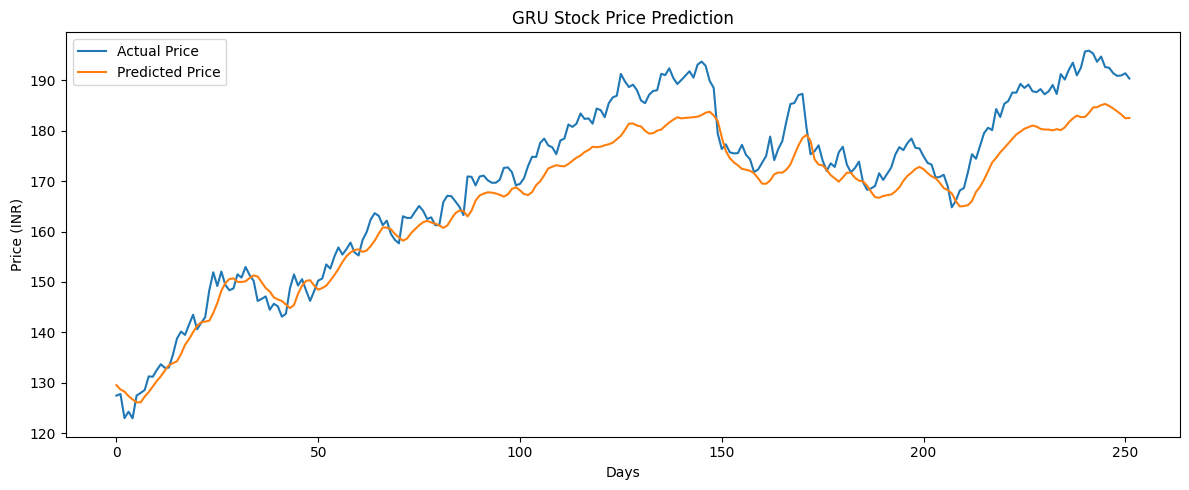

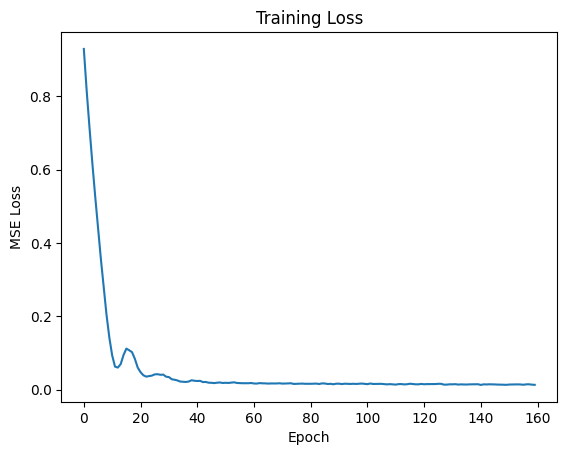

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_actual, label='Actual Price', linewidth=1.5)
plt.plot(preds_actual, label='Predicted Price', linewidth=1.5)
plt.title('GRU Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_prediction.png', dpi=150)
plt.show()

# Loss curve
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.savefig('loss_curve.png')
plt.show()

In [21]:
torch.save(final_model.state_dict(),"stock_model.pth")

In [22]:
import pickle

pickle.dump(
    scaler,
    open("scaler.pkl", "wb")
)

In [23]:
import pickle

pickle.dump(
    close_scaler,
    open("close_scaler.pkl", "wb")
)